### Distribution of left-handed versus right-handed players

In [19]:
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [20]:
match_parquet_path = "D:/Daneshkar/Project-1(Tennis)/data/input/tennis_data/**/data/raw/raw_match_parquet/*.parquet"
all_parquet_files = glob(match_parquet_path, recursive=True)
limit_folder = sorted(set(os.path.dirname(f) for f in all_parquet_files))
selected_folder = limit_folder[:]
selected_files = [f for f in all_parquet_files if os.path.dirname(f) in selected_folder]

dis_combined_df = pd.concat([pd.read_parquet(f) for f in selected_files], ignore_index=True)

C:\Users\moham\AppData\Local\Temp\ipykernel_14320\2757412251.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dis_combined_df = pd.concat([pd.read_parquet(f) for f in selected_files], ignore_index=True)


In [21]:
display(dis_combined_df)
display(dis_combined_df.info(()))

,match_id,name,slug,gender,user_count,residence,birthplace,height,weight,plays,...,tennis_points,has_event_player_statistics,crowd_sourcing_enabled,has_performance_graph_feature,display_inverse_home_away_teams,priority,competition_type,city,stadium,venue_id
0,11998445,Auger-Aliassime F.,auger-aliassime-felix,M,23318.0,"Monte Carlo, Monaco","Montreal, Canada",1.93,87.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11998446,Cobolli F.,flavio-cobolli,M,5995.0,Rome,"Florence, Italy",1.83,71.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11998447,Martínez P.,martinez-pedro,M,2621.0,"Valencia, Spain","Alzira, Spain",1.85,76.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11998448,Muller A.,muller-alexandre,M,2443.0,France,"Poissy, France",1.83,73.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11998449,Mayot H.,mayot-harold,M,1492.0,"Marly, France","Metz, France",1.78,78.0,right-handed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316797,12213482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hammamet,Court 5,18337.0
316798,12213483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hammamet,Court 8,18581.0
316799,12213484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hammamet,Court 6,18336.0
316800,12213486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Hammamet,Court 7,18289.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316802 entries, 0 to 316801
Data columns (total 62 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   match_id                         316802 non-null  int64  
 1   name                             104767 non-null  object 
 2   slug                             69096 non-null   object 
 3   gender                           49745 non-null   object 
 4   user_count                       85484 non-null   float64
 5   residence                        14205 non-null   object 
 6   birthplace                       28669 non-null   object 
 7   height                           27861 non-null   float64
 8   weight                           13942 non-null   float64
 9   plays                            24443 non-null   object 
 10  turned_pro                       9531 non-null    object 
 11  current_prize                    49457 non-null   float64
 12  to

None

In [44]:
# Filter right- and left-handed players
right_hand_df = dis_combined_df[dis_combined_df['plays'] == 'right-handed']
left_hand_df = dis_combined_df[dis_combined_df['plays'] == 'left-handed']

# Drop duplicate players based on player_id (to avoid counting same player multiple times)
right_hand_unique = right_hand_df.drop_duplicates(subset='player_id')
left_hand_unique = left_hand_df.drop_duplicates(subset='player_id')

# Count
r_count = len(right_hand_unique)
l_count = len(left_hand_unique)

# Print result
print(f"Amount of right-handed players: {r_count}")
print(f"Amount of left-handed players: {l_count}")

# Percantage of each group
total_count = sum((r_count,l_count))
per_right = (r_count/total_count)*100
per_left = (l_count/total_count)*100
print(f"\nproportion of right-handed player: {per_right:.2f}%")
print(f"proportion of left-handed player: {per_left:.2f}%")

Amount of right-handed players: 1013
Amount of left-handed players: 133

proportion of right-handed player: 88.39%
proportion of left-handed player: 11.61%


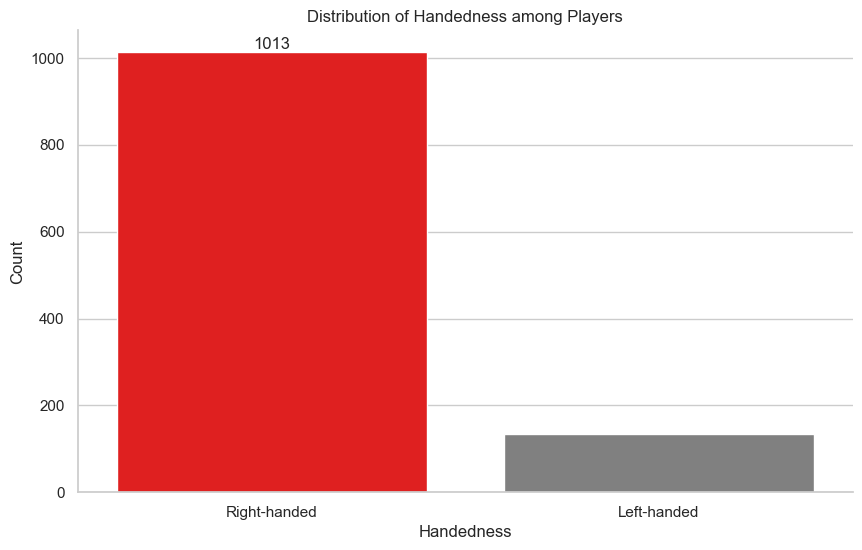

In [37]:
# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Set 'Handedness' as hue to comply with Seaborn's future requirement
ax = sns.barplot(
    x='Handedness', 
    y='Count', 
    hue='Handedness', 
    data = hand_data, 
    palette=['red', 'gray'],
    legend=False  # Disable legend since it's redundant
)

# Customize
ax.set_title("Distribution of Handedness among Players")
ax.bar_label(ax.containers[0])  # Add values on top of bars
sns.despine()

plt.show()